## Imports

In [14]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import pandas as pd
import torch
import torch.nn as nn
from scipy.ndimage import binary_erosion
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.transform import resize
from IPython.display import display

## Configuration

In [15]:
MODEL_VARIANT = "L1_only"
RUN_NAME = "final_train"  # Copy the exact run name printed by train.ipynb.
CHECKPOINT_FILENAME = f"{RUN_NAME}_best.pt"
CHANNELS = [8, 16, 32, 64]
CROP_SIZE = 80
DEGRADATION_GRID_SIZE = 96
SCALE_FACTOR = 1.5
BATCH_SIZE = 32
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0

REAL_CALIBRATION_FRACTION = 0.25
PAIRING_DICE_LOWER_QUANTILE = 0.05
PAIRING_DISTANCE_UPPER_QUANTILE = 0.95
EXCLUDE_FALLBACK_FROM_PRIMARY = True
IQT_LR_ROOT = None
SUMMARY_DDOF = 1
LUNG_EROSION_ITERATIONS = 1
EXPECTED_LOSS_NAME = "l1_plus_finite_difference_gradient"
EXPECTED_GRADIENT_LOSS_WEIGHT = 0.1

candidate_output_dirs = [Path.cwd(), Path.cwd() / "Development"]
OUTPUT_DIR = next(
    (d / "Outputs" for d in candidate_output_dirs if (d / "Outputs").exists()),
    Path.cwd() / "Outputs",
)
EXPORT_PATH = OUTPUT_DIR / "iqt_real_pairs_export.npz"
RESULTS_PATH = OUTPUT_DIR / f"iqt_real_{RUN_NAME}_test_metrics.csv"
CHECKPOINT_PATH = OUTPUT_DIR / "checkpoints" / CHECKPOINT_FILENAME

assert MODEL_VARIANT
assert EXPORT_PATH.exists(), f"Test export not found at {EXPORT_PATH.resolve()}"
assert CHECKPOINT_PATH.exists(), (
    f"Explicit checkpoint not found at {CHECKPOINT_PATH.resolve()}. "
    "Copy RUN_NAME exactly from train.ipynb. Automatic newest-file selection is disabled."
)

torch.manual_seed(SEED)

print("device:", DEVICE)
print("model variant:", MODEL_VARIANT)
print("run:", RUN_NAME)
print("checkpoint:", CHECKPOINT_PATH)
print("real calibration fraction:", REAL_CALIBRATION_FRACTION)


device: cuda
model variant: L1_only
run: final_train
checkpoint: c:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\checkpoints\final_train_best.pt
real calibration fraction: 0.25


## Data Preparation

In [16]:
test_data = np.load(EXPORT_PATH, allow_pickle=True)
print("export arrays:", list(test_data.files))

required_arrays = [
    "lr_frames", "hr_frames", "slice", "lr_dynamic", "hr_dynamic", "included",
    "fallback", "phase_pairing_distance", "mean_dice", "evaluation_mask", "mask_valid",
]
missing = [key for key in required_arrays if key not in test_data.files]
assert not missing, f"Real-pair export is missing {missing}; rerun preprocessing.ipynb Step 9."

included = test_data["included"].astype(bool)
all_lr_frames = test_data["lr_frames"][included]
all_hr_frames = test_data["hr_frames"][included]
all_sl = test_data["slice"][included]
all_lr_dynamic = test_data["lr_dynamic"][included]
all_hr_dynamic = test_data["hr_dynamic"][included]
all_fallback = test_data["fallback"][included].astype(bool)
all_phase_distance = test_data["phase_pairing_distance"][included].astype(float)
all_mean_dice = test_data["mean_dice"][included].astype(float)
all_evaluation_mask = test_data["evaluation_mask"][included].astype(bool)
all_mask_valid = test_data["mask_valid"][included].astype(bool)
all_subject_id = (
    test_data["subject_id"][included].astype(str)
    if "subject_id" in test_data.files
    else np.full(len(all_lr_frames), "IQT_REAL")
)

assert len({len(x) for x in [
    all_lr_frames, all_hr_frames, all_sl, all_lr_dynamic, all_hr_dynamic,
    all_fallback, all_phase_distance, all_mean_dice, all_evaluation_mask, all_mask_valid,
]}) == 1
assert all_lr_frames.shape == all_hr_frames.shape == all_evaluation_mask.shape

# Split by reused HR target, not LR dynamic. This guarantees that calibration and
# held-out evaluation cannot contain frames derived from the same HR dynamic.
unique_hr_groups = np.unique(all_hr_dynamic)
calibration_rng = np.random.default_rng(SEED)
shuffled_hr_groups = unique_hr_groups.copy()
calibration_rng.shuffle(shuffled_hr_groups)
n_calibration_groups = max(1, int(round(len(shuffled_hr_groups) * REAL_CALIBRATION_FRACTION)))
calibration_hr_groups = shuffled_hr_groups[:n_calibration_groups]

real_calibration_mask = np.isin(all_hr_dynamic, calibration_hr_groups)
real_heldout_mask = ~real_calibration_mask
assert real_calibration_mask.any() and real_heldout_mask.any()
assert set(all_hr_dynamic[real_calibration_mask]).isdisjoint(set(all_hr_dynamic[real_heldout_mask]))
assert set(all_lr_dynamic[real_calibration_mask]).isdisjoint(set(all_lr_dynamic[real_heldout_mask]))

# Derive pairing-quality cut-offs only from non-fallback calibration pairs.
calibration_pair_rows = pd.DataFrame({
    "lr_dynamic": all_lr_dynamic[real_calibration_mask],
    "hr_dynamic": all_hr_dynamic[real_calibration_mask],
    "fallback": all_fallback[real_calibration_mask],
    "mean_dice": all_mean_dice[real_calibration_mask],
    "phase_distance": all_phase_distance[real_calibration_mask],
}).drop_duplicates(["lr_dynamic", "hr_dynamic"])
calibration_qc = calibration_pair_rows[
    (~calibration_pair_rows["fallback"])
    & calibration_pair_rows["mean_dice"].notna()
    & calibration_pair_rows["phase_distance"].notna()
]
assert len(calibration_qc) >= 2, "Too few non-fallback calibration pairs to derive QC thresholds"
min_pair_mean_dice = float(calibration_qc["mean_dice"].quantile(PAIRING_DICE_LOWER_QUANTILE))
max_phase_pairing_distance = float(calibration_qc["phase_distance"].quantile(PAIRING_DISTANCE_UPPER_QUANTILE))

relaxed_qc_mask = all_mask_valid.copy()
if EXCLUDE_FALLBACK_FROM_PRIMARY:
    relaxed_qc_mask &= ~all_fallback
strict_qc_mask = (
    relaxed_qc_mask
    & (all_mean_dice >= min_pair_mean_dice)
    & (all_phase_distance <= max_phase_pairing_distance)
)

primary_mask_all = real_heldout_mask & strict_qc_mask
assert primary_mask_all.any(), "Strict pairing QC removed every held-out pair"

heldout_indices = np.flatnonzero(real_heldout_mask)
lr_frames = all_lr_frames[real_heldout_mask]
hr_frames = all_hr_frames[real_heldout_mask]
sl = all_sl[real_heldout_mask]
lr_dynamic = all_lr_dynamic[real_heldout_mask]
hr_dynamic = all_hr_dynamic[real_heldout_mask]
fallback = all_fallback[real_heldout_mask]
phase_pairing_distance = all_phase_distance[real_heldout_mask]
mean_dice = all_mean_dice[real_heldout_mask]
evaluation_mask = all_evaluation_mask[real_heldout_mask]
mask_valid = all_mask_valid[real_heldout_mask]
relaxed_qc = relaxed_qc_mask[real_heldout_mask]
primary_qc = strict_qc_mask[real_heldout_mask]
erosion_structure = np.ones((3, 3), dtype=bool)
eroded_evaluation_mask = np.stack([
    binary_erosion(mask, structure=erosion_structure, iterations=LUNG_EROSION_ITERATIONS)
    for mask in evaluation_mask
])
eroded_mask_valid = eroded_evaluation_mask.reshape(len(eroded_evaluation_mask), -1).any(axis=1)

assert not fallback[primary_qc].any()
assert mask_valid[primary_qc].all()
assert eroded_mask_valid[primary_qc].all()
assert np.all(mean_dice[primary_qc] >= min_pair_mean_dice)
assert np.all(phase_pairing_distance[primary_qc] <= max_phase_pairing_distance)

print("WARNING: real evaluation contains", len(np.unique(all_subject_id)), "subject only; no population-level claim is valid.")
print("included rows:", len(all_lr_frames))
print("unique LR dynamics / HR targets / LR-HR pairs:",
      len(np.unique(all_lr_dynamic)), len(np.unique(all_hr_dynamic)),
      len(set(zip(all_lr_dynamic.tolist(), all_hr_dynamic.tolist()))))
print("calibration HR targets:", sorted(calibration_hr_groups.tolist()))
print("held-out HR targets:", sorted(np.unique(hr_dynamic).tolist()))
print("calibration / held-out rows:", int(real_calibration_mask.sum()), len(lr_frames))
print(f"primary strict-QC thresholds from calibration: mean Dice >= {min_pair_mean_dice:.4f}, "
      f"phase distance <= {max_phase_pairing_distance:.4f}")
print("primary exclusions: invalid lung mask and fallback pairing =", EXCLUDE_FALLBACK_FROM_PRIMARY)
print("primary strict-QC held-out rows / unique LR-HR pairs:", int(primary_qc.sum()),
      len(set(zip(lr_dynamic[primary_qc].tolist(), hr_dynamic[primary_qc].tolist()))))
print("relaxed-QC sensitivity rows / unique LR-HR pairs:", int(relaxed_qc.sum()),
      len(set(zip(lr_dynamic[relaxed_qc].tolist(), hr_dynamic[relaxed_qc].tolist()))))


export arrays: ['lr_frames', 'hr_frames', 'lr_lung_mask', 'hr_lung_mask', 'evaluation_mask', 'subject_id', 'slice', 'lr_dynamic', 'hr_dynamic', 'echo', 'phase_bin', 'direction', 'fallback', 'phase_pairing_distance', 'mean_dice', 'slice_dice', 'n_slices_scored', 'mask_valid', 'anchor_row', 'anchor_col', 'crop_origin_row', 'crop_origin_col', 'landmark_diaphragm_y', 'landmark_mid_x', 'lr_native_size', 'hr_native_size', 'included', 'exclusion_reason']
included rows: 180
unique LR dynamics / HR targets / LR-HR pairs: 30 7 30
calibration HR targets: [12, 20]
held-out HR targets: [1, 11, 19, 29, 30]
calibration / held-out rows: 72 108
primary strict-QC thresholds from calibration: mean Dice >= 0.8378, phase distance <= 456.9800
primary exclusions: invalid lung mask and fallback pairing = True
primary strict-QC held-out rows / unique LR-HR pairs: 56 10
relaxed-QC sensitivity rows / unique LR-HR pairs: 62 11


In [17]:
def compute_percentile_scale_by_slice(frames, slices, mask, low=1, high=99):
    scale = {}
    for slice_id in np.unique(slices[mask]):
        calibration_frames = frames[mask & (slices == slice_id)]
        assert len(calibration_frames) > 0, f"No calibration frames for slice {slice_id}"
        scale[slice_id] = tuple(np.percentile(calibration_frames, [low, high]))
    return scale


def normalise(img, lo, hi):
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0.0, 1.0)


percentile_scale = compute_percentile_scale_by_slice(all_lr_frames, all_sl, real_calibration_mask)
missing_slices = sorted(set(sl.tolist()) - set(percentile_scale))
assert not missing_slices, f"Held-out slices missing calibration bounds: {missing_slices}"

lo_bounds = np.array([percentile_scale[s][0] for s in sl])[:, None, None]
hi_bounds = np.array([percentile_scale[s][1] for s in sl])[:, None, None]

hr_clip_below_map = hr_frames < lo_bounds
hr_clip_above_map = hr_frames > hi_bounds
lr_clip_below_map = lr_frames < lo_bounds
lr_clip_above_map = lr_frames > hi_bounds

def percent_true(values, mask=None):
    values = np.asarray(values, dtype=bool)
    if mask is None:
        return float(values.mean() * 100)
    mask = np.asarray(mask, dtype=bool)
    assert mask.shape == values.shape and mask.any()
    return float(values[mask].mean() * 100)


print(f"held-out LR clipping, whole crop: {percent_true(lr_clip_below_map):.2f}% below, "
      f"{percent_true(lr_clip_above_map):.2f}% above")
print(f"held-out HR clipping, whole crop: {percent_true(hr_clip_below_map):.2f}% below, "
      f"{percent_true(hr_clip_above_map):.2f}% above")
valid_lung_pixels = evaluation_mask & mask_valid[:, None, None]
print(f"held-out LR clipping, lung union: {percent_true(lr_clip_below_map, valid_lung_pixels):.2f}% below, "
      f"{percent_true(lr_clip_above_map, valid_lung_pixels):.2f}% above")
print(f"held-out HR clipping, lung union: {percent_true(hr_clip_below_map, valid_lung_pixels):.2f}% below, "
      f"{percent_true(hr_clip_above_map, valid_lung_pixels):.2f}% above")

# Calibration-only additive shift is a protocol-gap diagnostic, not an SR baseline.
protocol_shift_by_slice = {}
for slice_id in np.unique(all_sl):
    use = real_calibration_mask & (all_sl == slice_id) & all_mask_valid & ~all_fallback
    assert use.any(), f"No valid calibration masks for slice {slice_id}"
    lo, hi = percentile_scale[slice_id]
    lr_n = normalise(all_lr_frames[use], lo, hi)
    hr_n = normalise(all_hr_frames[use], lo, hi)
    mask_n = all_evaluation_mask[use]
    protocol_shift_by_slice[slice_id] = float(np.median((hr_n - lr_n)[mask_n]))
print("calibration-derived lung intensity shifts by slice:",
      {int(k): round(v, 4) for k, v in protocol_shift_by_slice.items()})


held-out LR clipping, whole crop: 0.00% below, 1.21% above
held-out HR clipping, whole crop: 0.00% below, 6.55% above
held-out LR clipping, lung union: 0.00% below, 0.00% above
held-out HR clipping, lung union: 0.00% below, 0.00% above
calibration-derived lung intensity shifts by slice: {1: -0.0523, 2: -0.0735, 3: -0.0527, 4: -0.0433, 5: -0.0275, 6: -0.0151}


In [18]:
def find_native_lr_root(native_size):
    if IQT_LR_ROOT is not None:
        root = Path(IQT_LR_ROOT)
        assert root.is_dir(), f"Native LR folder not found: {root}"
        return root

    output = OUTPUT_DIR.resolve()
    iqt_root = next((p / "IQT" for p in [output, *output.parents] if (p / "IQT").is_dir()), None)
    if iqt_root is None:
        raise FileNotFoundError(
            "Native IQT LR .hdr/.img files are needed for interpolation baselines. "
            "Set IQT_LR_ROOT to their folder."
        )
    candidates = sorted({p.parent for p in iqt_root.rglob("IM-*-*-*.hdr")})
    matches = [
        p for p in candidates
        if tuple(nib.load(str(next(p.glob("IM-*-*-*.hdr")))).shape[:2]) == (native_size, native_size)
    ]
    assert len(matches) == 1, f"Expected one native {native_size}x{native_size} IQT LR folder, found {matches}"
    return matches[0]


def make_linear_baseline():
    required = ["echo", "crop_origin_row", "crop_origin_col", "lr_native_size", "hr_native_size"]
    missing = [key for key in required if key not in test_data.files]
    assert not missing, f"Interpolation geometry metadata missing: {missing}"
    selected = np.flatnonzero(included)[real_heldout_mask]
    geometry = {}
    for key in required:
        values = np.asarray(test_data[key])
        assert values.shape == included.shape, f"Metadata shape mismatch: {key}"
        geometry[key] = values[selected]
        assert np.isfinite(geometry[key]).all(), f"Non-finite metadata: {key}"
        assert np.equal(geometry[key], np.floor(geometry[key])).all(), f"Non-integer metadata: {key}"

    native_sizes = np.unique(geometry["lr_native_size"])
    assert len(native_sizes) == 1
    native_root = find_native_lr_root(int(native_sizes[0]))
    print("native LR source:", native_root)
    linear_frames = []
    native_cache = {}
    maximum_difference = 0.0
    height, width = lr_frames.shape[1:]

    for i in range(len(lr_frames)):
        slice_id, echo, dynamic = int(sl[i]), int(geometry["echo"][i]), int(lr_dynamic[i])
        key = (slice_id, echo, dynamic)
        if key not in native_cache:
            hdr = native_root / f"IM-{slice_id:02d}-{echo:02d}-{dynamic:03d}.hdr"
            assert hdr.exists(), f"Native LR frame not found: {hdr}"
            native_cache[key] = np.rot90(np.squeeze(nib.load(str(hdr)).get_fdata()), k=1)
        native = native_cache[key]
        native_size = int(geometry["lr_native_size"][i])
        target_size = int(geometry["hr_native_size"][i])
        assert native.shape == (native_size, native_size)
        y0, x0 = int(geometry["crop_origin_row"][i]), int(geometry["crop_origin_col"][i])
        assert 0 <= y0 <= target_size - height and 0 <= x0 <= target_size - width

        cropped = {}
        for order in (1, 3):
            upsampled = resize(
                native, (target_size, target_size), order=order, mode="edge",
                anti_aliasing=False, preserve_range=True,
            )
            cropped[order] = upsampled[y0:y0 + height, x0:x0 + width].astype(np.float32)

        difference = float(np.max(np.abs(cropped[3] - lr_frames[i])))
        maximum_difference = max(maximum_difference, difference)
        assert np.allclose(cropped[3], lr_frames[i], rtol=1e-5, atol=1e-5), (
            f"Rebuilt bicubic input does not match export for {key}, max difference {difference:g}"
        )
        linear_frames.append(cropped[1])

    print(f"bicubic/export verification passed; maximum absolute difference: {maximum_difference:g}")
    return np.stack(linear_frames)


linear_frames = make_linear_baseline()


class RealPairDataset(torch.utils.data.Dataset):
    def __init__(self, lr_frames, hr_frames, slices, scale):
        self.lr_frames = lr_frames
        self.hr_frames = hr_frames
        self.slices = slices
        self.scale = scale

    def __len__(self):
        return len(self.lr_frames)

    def __getitem__(self, i):
        lo, hi = self.scale[self.slices[i]]
        lr = torch.from_numpy(normalise(self.lr_frames[i], lo, hi)).float().unsqueeze(0)
        hr = torch.from_numpy(normalise(self.hr_frames[i], lo, hi)).float().unsqueeze(0)
        return lr, hr


test_ds = RealPairDataset(lr_frames, hr_frames, sl, percentile_scale)
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=DEVICE == "cuda",
)


native LR source: C:\Users\User\Desktop\MSc\MSc Project\IQT\LR
bicubic/export verification passed; maximum absolute difference: 0


## Model

In [19]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, channels):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.pool = nn.MaxPool2d(2)
        self.enc1 = ConvBlock(1, c1)
        self.enc2 = ConvBlock(c1, c2)
        self.enc3 = ConvBlock(c2, c3)
        self.enc4 = ConvBlock(c3, c4)
        self.bottleneck = ConvBlock(c4, c4)
        self.up4 = nn.ConvTranspose2d(c4, c4, 2, stride=2)
        self.dec4 = ConvBlock(c4 + c4, c3)
        self.up3 = nn.ConvTranspose2d(c3, c3, 2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c2)
        self.up2 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c1)
        self.up1 = nn.ConvTranspose2d(c1, c1, 2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.out_conv = nn.Conv2d(c1, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


def load_checkpoint(path, expected_channels):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    assert isinstance(checkpoint, dict) and "state_dict" in checkpoint, (
        "Legacy bare state_dict rejected. Retrain with the revised train.ipynb."
    )
    required = [
        "format_version", "run_name", "model_variant", "channels", "epoch",
        "selection_metric", "selection_value", "degradation_grid_size", "scale_factor",
        "train_subjects", "val_subject", "test_subject",
        "loss_name", "gradient_loss_weight",
    ]
    missing = [key for key in required if key not in checkpoint]
    assert not missing, f"Checkpoint provenance metadata missing: {missing}"
    assert checkpoint["format_version"] >= 2
    assert checkpoint["run_name"] == RUN_NAME
    assert checkpoint["model_variant"] == MODEL_VARIANT
    assert list(checkpoint["channels"]) == list(expected_channels)
    assert checkpoint["degradation_grid_size"] == DEGRADATION_GRID_SIZE
    assert np.isclose(checkpoint["scale_factor"], SCALE_FACTOR)
    assert checkpoint["loss_name"] == EXPECTED_LOSS_NAME
    # assert np.isclose(checkpoint["gradient_loss_weight"], EXPECTED_GRADIENT_LOSS_WEIGHT)
    print("checkpoint provenance:", {key: checkpoint[key] for key in required if key != "channels"})
    print("checkpoint channels:", checkpoint["channels"])
    return checkpoint["state_dict"]


torch.manual_seed(SEED)
model = UNet(CHANNELS).to(DEVICE)
state_dict = load_checkpoint(CHECKPOINT_PATH, CHANNELS)
model.load_state_dict(state_dict, strict=True)
model.eval()
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


checkpoint provenance: {'format_version': 2, 'run_name': 'final_train', 'model_variant': 'L1_only', 'epoch': 38, 'selection_metric': 'lung_psnr', 'selection_value': 37.37340050958074, 'degradation_grid_size': 96, 'scale_factor': 1.5, 'train_subjects': ['TV1_20220222_sorted_UCL', 'TV2_20220222_sorted_UCL', 'TV3_20220208_sorted_UCL', 'TV5_20220307_sorted_UCL', 'TV6_20220307_sorted_UCL', 'TV7_20220315_sorted_UCL'], 'val_subject': 'TV4_20220204_sorted_UCL', 'test_subject': 'TV8_20220307_sorted_UCL', 'loss_name': 'l1_plus_finite_difference_gradient', 'gradient_loss_weight': 0.0}
checkpoint channels: [8, 16, 32, 64]
trainable parameters: 232537


## Inference

In [20]:
def frame_rmse(prediction, target, mask=None):
    difference = prediction.astype(np.float64) - target.astype(np.float64)
    if mask is not None:
        mask = np.asarray(mask, dtype=bool)
        assert mask.any()
        difference = difference[mask]
    return float(np.sqrt(np.mean(difference ** 2)))


def frame_metrics(prediction, target, mask=None):
    if mask is None:
        return {
            "psnr": peak_signal_noise_ratio(target, prediction, data_range=1.0),
            "ssim": structural_similarity(target, prediction, data_range=1.0),
            "rmse": frame_rmse(prediction, target),
        }
    mask = np.asarray(mask, dtype=bool)
    assert mask.any()
    mse = float(np.mean((prediction[mask].astype(np.float64) - target[mask].astype(np.float64)) ** 2))
    psnr = float("inf") if mse == 0 else -10.0 * np.log10(mse)
    _, ssim_map = structural_similarity(target, prediction, data_range=1.0, full=True)
    return {"psnr": psnr, "ssim": float(ssim_map[mask].mean()), "rmse": float(np.sqrt(mse))}


linear_images, lr_images, pred_images, hr_images, residual_images = [], [], [], [], []
rows = []
frame_offset = 0

with torch.no_grad():
    for lr, hr in test_loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        pred_residual = model(lr)
        prediction = (lr + pred_residual).clamp(0.0, 1.0)

        lr_np = lr[:, 0].cpu().numpy()
        pred_np = prediction[:, 0].cpu().numpy()
        hr_np = hr[:, 0].cpu().numpy()
        residual_np = pred_residual[:, 0].cpu().numpy()
        lr_images.append(lr_np)
        pred_images.append(pred_np)
        hr_images.append(hr_np)
        residual_images.append(residual_np)

        for j, (lr_i, pred_i, hr_i, residual_i) in enumerate(zip(lr_np, pred_np, hr_np, residual_np)):
            i = frame_offset + j
            lo, hi = percentile_scale[sl[i]]
            linear_i = normalise(linear_frames[i], lo, hi).astype(np.float32)
            protocol_i = np.clip(lr_i + protocol_shift_by_slice[sl[i]], 0.0, 1.0)
            mask_i = evaluation_mask[i]
            eroded_mask_i = eroded_evaluation_mask[i]
            linear_images.append(linear_i)

            method_images = {
                "linear": linear_i,
                "baseline": lr_i,
                "model": pred_i,
                "protocol_shift": protocol_i,
            }
            row = {
                "slice": int(sl[i]),
                "lr_dynamic": int(lr_dynamic[i]),
                "hr_dynamic": int(hr_dynamic[i]),
                "fallback": bool(fallback[i]),
                "phase_pairing_distance": float(phase_pairing_distance[i]),
                "mean_dice": float(mean_dice[i]),
                "mask_valid": bool(mask_valid[i]),
                "eroded_mask_valid": bool(eroded_mask_valid[i]),
                "relaxed_qc": bool(relaxed_qc[i]),
                "primary_qc": bool(primary_qc[i]),
                "lr_mean": float(lr_i.mean()),
                "prediction_mean": float(pred_i.mean()),
                "hr_mean": float(hr_i.mean()),
                "residual_mean": float(residual_i.mean()),
                "hr_clip_above_fraction": float(hr_clip_above_map[i].mean()),
                "hr_clip_above_lung_fraction": float(hr_clip_above_map[i][mask_i].mean()) if mask_i.any() else np.nan,
            }
            for prefix, image in method_images.items():
                whole = frame_metrics(image, hr_i)
                lung = frame_metrics(image, hr_i, mask_i) if mask_valid[i] and mask_i.any() else {k: np.nan for k in ("psnr", "ssim", "rmse")}
                eroded_lung = frame_metrics(image, hr_i, eroded_mask_i) if eroded_mask_valid[i] else {k: np.nan for k in ("psnr", "ssim", "rmse")}
                for metric, value in whole.items():
                    row[f"{prefix}_{metric}"] = value
                for metric, value in lung.items():
                    row[f"{prefix}_lung_{metric}"] = value
                for metric, value in eroded_lung.items():
                    row[f"{prefix}_eroded_lung_{metric}"] = value
            rows.append(row)

        frame_offset += len(lr_np)

linear_images = np.stack(linear_images)
lr_images = np.concatenate(lr_images)
pred_images = np.concatenate(pred_images)
hr_images = np.concatenate(hr_images)
residual_images = np.concatenate(residual_images)

results = pd.DataFrame(rows)
results["psnr_gain"] = results["model_psnr"] - results["baseline_psnr"]
results["ssim_gain"] = results["model_ssim"] - results["baseline_ssim"]
results["rmse_difference"] = results["model_rmse"] - results["baseline_rmse"]
results["lung_psnr_gain"] = results["model_lung_psnr"] - results["baseline_lung_psnr"]
results["lung_ssim_gain"] = results["model_lung_ssim"] - results["baseline_lung_ssim"]
results["lung_rmse_difference"] = results["model_lung_rmse"] - results["baseline_lung_rmse"]
results["eroded_lung_psnr_gain"] = results["model_eroded_lung_psnr"] - results["baseline_eroded_lung_psnr"]
results["eroded_lung_ssim_gain"] = results["model_eroded_lung_ssim"] - results["baseline_eroded_lung_ssim"]
results["eroded_lung_rmse_difference"] = results["model_eroded_lung_rmse"] - results["baseline_eroded_lung_rmse"]
results["lr_bias"] = results["lr_mean"] - results["hr_mean"]
results["prediction_bias"] = results["prediction_mean"] - results["hr_mean"]

assert len(results) == int(real_heldout_mask.sum())
results.to_csv(RESULTS_PATH, index=False)


## Results

In [21]:
primary_results = results[results["primary_qc"]].copy()
assert not primary_results.empty
relaxed_results = results[results["relaxed_qc"]].copy()

# Average the available correlated slice rows within each LR-HR dynamic pair first.
pair_results = (
    primary_results
    .groupby(["lr_dynamic", "hr_dynamic"], as_index=False)
    .mean(numeric_only=True)
)
hr_target_results = pair_results.groupby("hr_dynamic", as_index=False).mean(numeric_only=True)
relaxed_pair_results = (
    relaxed_results
    .groupby(["lr_dynamic", "hr_dynamic"], as_index=False)
    .mean(numeric_only=True)
)
relaxed_hr_target_results = relaxed_pair_results.groupby("hr_dynamic", as_index=False).mean(numeric_only=True)

assert hr_target_results["hr_dynamic"].is_unique
assert len(hr_target_results) == primary_results["hr_dynamic"].nunique()
assert not primary_results["fallback"].any()
assert primary_results["mask_valid"].all()
assert primary_results["eroded_mask_valid"].all()

def make_comparison_table(grouped, region="lung"):
    method_columns = {"Linear": "linear", "Bicubic": "baseline", "U-Net": "model"}
    rows = []
    for method, prefix in method_columns.items():
        row = {"Method": method}
        for metric in ("PSNR", "SSIM", "RMSE"):
            middle = {"whole": "", "lung": "_lung", "eroded_lung": "_eroded_lung"}[region]
            values = grouped[f"{prefix}{middle}_{metric.lower()}"]
            row[metric] = f"{values.mean():.{2 if metric == 'PSNR' else 4}f} ± {values.std(ddof=SUMMARY_DDOF):.{2 if metric == 'PSNR' else 4}f}"
        rows.append(row)
    return pd.DataFrame(rows)


print("PRIMARY RESULT: strict-QC lung-union metrics, mean ± sample SD across unique HR targets")
display(make_comparison_table(hr_target_results, region="lung").style.hide(axis="index"))

print("\nSENSITIVITY: whole-crop metrics across the same unique HR targets")
display(make_comparison_table(hr_target_results, region="whole").style.hide(axis="index"))

print("\nSENSITIVITY: one-pixel-eroded lung-union metrics across unique HR targets")
display(make_comparison_table(hr_target_results, region="eroded_lung").style.hide(axis="index"))

print("\nSENSITIVITY: relaxed-QC lung-union metrics across unique HR targets")
display(make_comparison_table(relaxed_hr_target_results, region="lung").style.hide(axis="index"))

def paired_difference_table(grouped, region="lung"):
    middle = {"whole": "", "lung": "_lung", "eroded_lung": "_eroded_lung"}[region]
    rows = []
    for metric in ("PSNR", "SSIM", "RMSE"):
        key = metric.lower()
        difference = grouped[f"model{middle}_{key}"] - grouped[f"baseline{middle}_{key}"]
        q1, q3 = difference.quantile([0.25, 0.75])
        improved = difference > 0 if metric != "RMSE" else difference < 0
        precision = 3 if metric == "PSNR" else 4
        rows.append({
            "Metric": metric,
            "Mean difference": f"{difference.mean():+.{precision}f}",
            "Sample SD": f"{difference.std(ddof=SUMMARY_DDOF):.{precision}f}",
            "Median difference": f"{difference.median():+.{precision}f}",
            "IQR": f"[{q1:+.{precision}f}, {q3:+.{precision}f}]",
            "Range": f"[{difference.min():+.{precision}f}, {difference.max():+.{precision}f}]",
            "HR targets improved": f"{int(improved.sum())}/{len(improved)} ({improved.mean() * 100:.1f}%)",
        })
    return pd.DataFrame(rows)


print("\nPAIRED PRIMARY DIFFERENCES: U-Net minus bicubic at the HR-target level")
print("Positive is better for PSNR/SSIM; negative is better for RMSE.")
display(paired_difference_table(hr_target_results, region="lung").style.hide(axis="index"))

target_differences = hr_target_results[["hr_dynamic"]].copy()
target_differences["psnr_difference"] = hr_target_results["model_lung_psnr"] - hr_target_results["baseline_lung_psnr"]
target_differences["ssim_difference"] = hr_target_results["model_lung_ssim"] - hr_target_results["baseline_lung_ssim"]
target_differences["rmse_difference"] = hr_target_results["model_lung_rmse"] - hr_target_results["baseline_lung_rmse"]
print("\nEvery primary HR-target cluster:")
display(target_differences.round({"psnr_difference": 3, "ssim_difference": 4, "rmse_difference": 4}).style.hide(axis="index"))

print("\nIndependence accounting:")
print("  subjects:", len(np.unique(all_subject_id)), "(population inference is impossible)")
print("  all held-out rows:", len(results))
print("  primary strict-QC rows:", len(primary_results))
print("  primary unique LR-HR pairs:", len(pair_results))
print("  primary independent HR-target clusters:", len(hr_target_results))
print("  relaxed-sensitivity unique LR-HR pairs:", len(relaxed_pair_results))
print("  calibration rows:", int(real_calibration_mask.sum()))
print("  inference status: single-subject case study; no population-level inference is valid")

print("\nModel gains across primary HR-target clusters:")
print(f"  lung PSNR/SSIM: {hr_target_results['lung_psnr_gain'].mean():+.3f} dB / {hr_target_results['lung_ssim_gain'].mean():+.4f}")
print(f"  whole PSNR/SSIM: {hr_target_results['psnr_gain'].mean():+.3f} dB / {hr_target_results['ssim_gain'].mean():+.4f}")
print(f"  HR targets with lung PSNR improvement: {(hr_target_results['lung_psnr_gain'] > 0).mean() * 100:.1f}%")

protocol_gain = hr_target_results["protocol_shift_lung_psnr"] - hr_target_results["baseline_lung_psnr"]
print("\nProtocol-gap diagnostic, calibration-derived additive intensity shift:")
print(f"  lung PSNR change vs bicubic: {protocol_gain.mean():+.3f} dB")
print("  This is not an SR method; it estimates how much of the score is simple cross-protocol intensity offset.")

print("\nPairing-quality sensitivity across every held-out pair, before primary-QC exclusion:")
all_pair_results = (
    results.groupby(["lr_dynamic", "hr_dynamic"], as_index=False)
    .agg(
        fallback=("fallback", "first"),
        mean_dice=("mean_dice", "first"),
        phase_pairing_distance=("phase_pairing_distance", "first"),
        lung_psnr_gain=("lung_psnr_gain", "mean"),
        lung_ssim_gain=("lung_ssim_gain", "mean"),
        primary_qc=("primary_qc", "first"),
    )
)
print(all_pair_results.groupby("fallback")[["lung_psnr_gain", "lung_ssim_gain"]].agg(["mean", "std", "count"]))
if all_pair_results["mean_dice"].nunique() > 1:
    all_pair_results["dice_band"] = pd.qcut(all_pair_results["mean_dice"], q=3, duplicates="drop")
    print("\nby pairing Dice tertile:")
    print(all_pair_results.groupby("dice_band", observed=True)[["lung_psnr_gain", "lung_ssim_gain"]].mean())
if all_pair_results["phase_pairing_distance"].nunique() > 1:
    all_pair_results["distance_band"] = pd.qcut(all_pair_results["phase_pairing_distance"], q=3, duplicates="drop")
    print("\nby phase-distance tertile:")
    print(all_pair_results.groupby("distance_band", observed=True)[["lung_psnr_gain", "lung_ssim_gain"]].mean())

print(f"\nmean predicted residual, equally weighted HR targets: {hr_target_results['residual_mean'].mean():+.4f}")
print(f"mean prediction intensity bias, equally weighted HR targets: {hr_target_results['prediction_bias'].mean():+.4f}")
print(f"mean HR clipping above 1, equally weighted HR targets: {hr_target_results['hr_clip_above_lung_fraction'].mean() * 100:.2f}%")
print("saved frame-level metrics with QC flags:", RESULTS_PATH)

print("\nPrimary lung metrics by slice:")
print(primary_results.groupby("slice")[[
    "baseline_lung_psnr", "model_lung_psnr", "lung_psnr_gain",
    "baseline_lung_ssim", "model_lung_ssim", "lung_ssim_gain",
]].mean().round(4))


PRIMARY RESULT: strict-QC lung-union metrics, mean ± sample SD across unique HR targets


Method,PSNR,SSIM,RMSE
Linear,21.79 ± 1.94,0.7831 ± 0.0212,0.0842 ± 0.0177
Bicubic,21.67 ± 2.09,0.7907 ± 0.0245,0.0858 ± 0.0195
U-Net,21.23 ± 2.19,0.7894 ± 0.0303,0.0907 ± 0.0215



SENSITIVITY: whole-crop metrics across the same unique HR targets


Method,PSNR,SSIM,RMSE
Linear,19.53 ± 1.49,0.7219 ± 0.0252,0.1074 ± 0.0190
Bicubic,19.54 ± 1.47,0.7343 ± 0.0256,0.1073 ± 0.0187
U-Net,19.27 ± 1.33,0.7338 ± 0.0242,0.1106 ± 0.0174



SENSITIVITY: one-pixel-eroded lung-union metrics across unique HR targets


...


PAIRED PRIMARY DIFFERENCES: U-Net minus bicubic at the HR-target level
Positive is better for PSNR/SSIM; negative is better for RMSE.


Metric,Mean difference,Sample SD,Median difference,IQR,Range,HR targets improved
PSNR,-0.443,0.207,-0.516,"[-0.587, -0.372]","[-0.591, -0.150]",0/4 (0.0%)
SSIM,-0.0014,0.0092,-0.0030,"[-0.0083, +0.0039]","[-0.0097, +0.0101]",2/4 (50.0%)
RMSE,+0.0049,0.0027,+0.0050,"[+0.0033, +0.0067]","[+0.0017, +0.0079]",0/4 (0.0%)



Every primary HR-target cluster:


hr_dynamic,psnr_difference,ssim_difference,rmse_difference
1,-0.150000,0.010100,0.001700
11,-0.591000,-0.009700,0.007900
19,-0.446000,0.001800,0.003800
29,-0.586000,-0.007800,0.006300



Independence accounting:
  subjects: 1 (population inference is impossible)
  all held-out rows: 108
  primary strict-QC rows: 56
  primary unique LR-HR pairs: 10
  primary independent HR-target clusters: 4
  relaxed-sensitivity unique LR-HR pairs: 11
  calibration rows: 72
  inference status: single-subject case study; no population-level inference is valid

Model gains across primary HR-target clusters:
  lung PSNR/SSIM: -0.443 dB / -0.0014
  whole PSNR/SSIM: -0.273 dB / -0.0006
  HR targets with lung PSNR improvement: 0.0%

Protocol-gap diagnostic, calibration-derived additive intensity shift:
  lung PSNR change vs bicubic: -1.295 dB
  This is not an SR method; it estimates how much of the score is simple cross-protocol intensity offset.

Pairing-quality sensitivity across every held-out pair, before primary-QC exclusion:
         lung_psnr_gain                 lung_ssim_gain                
                   mean       std count           mean       std count
fallback            

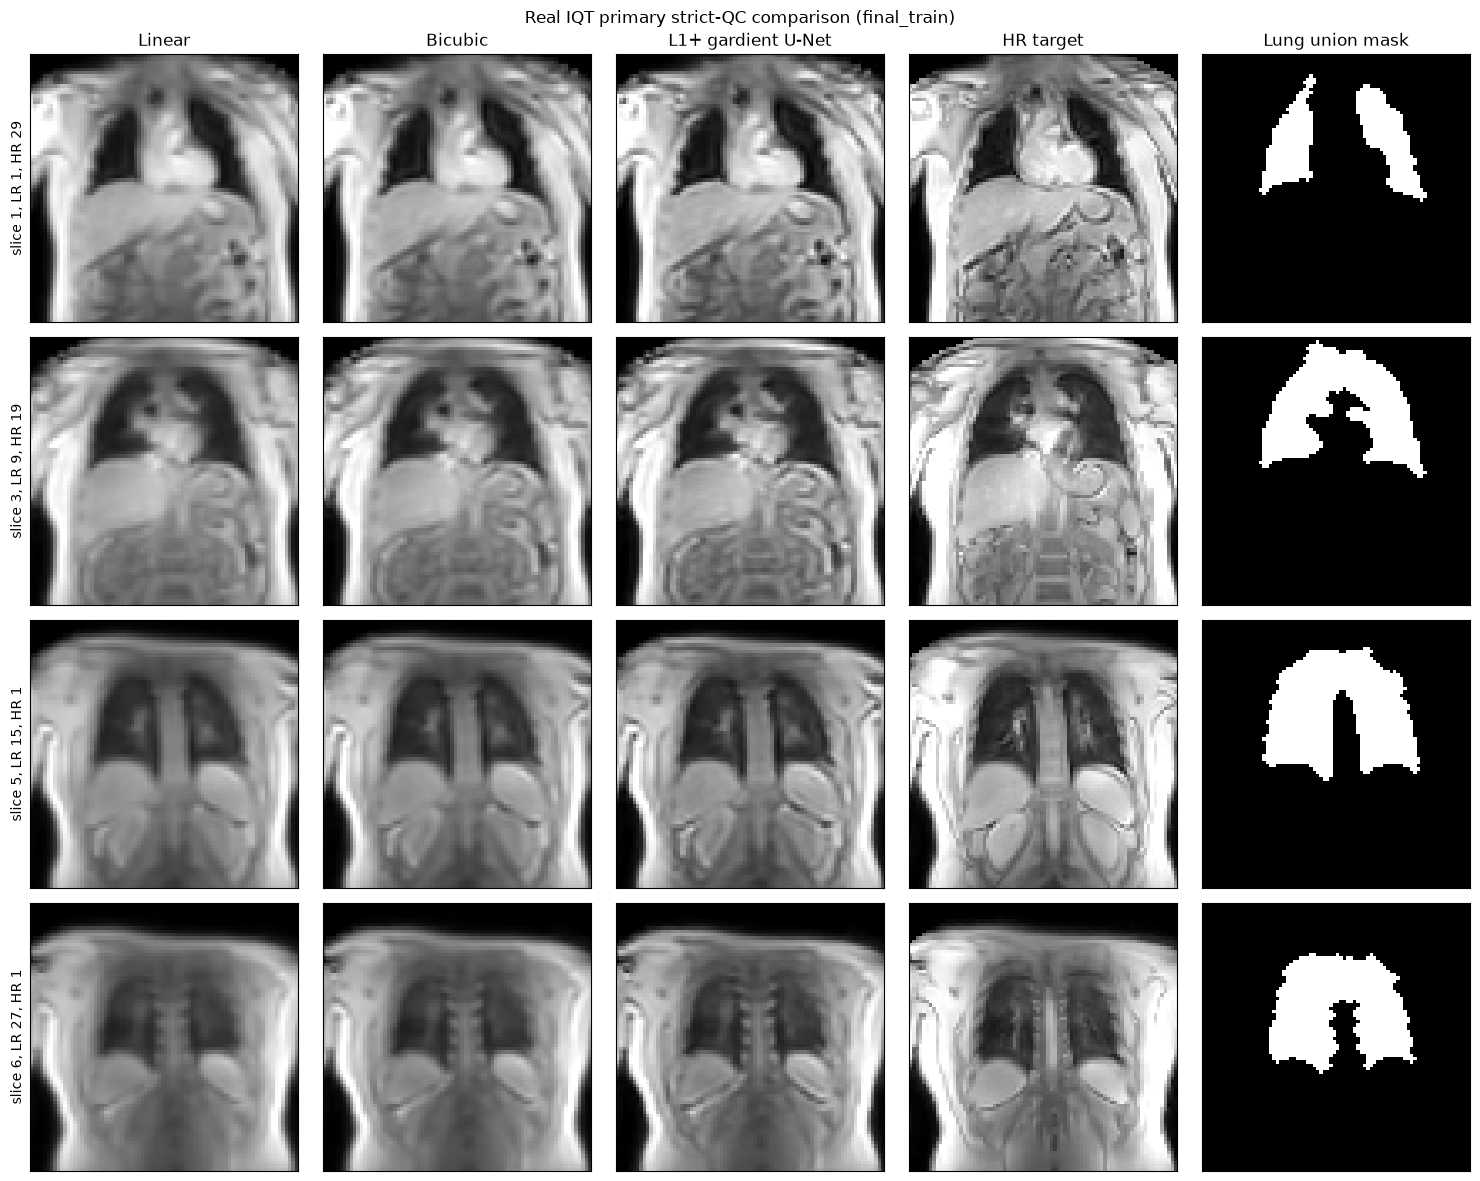

In [22]:
primary_positions = np.flatnonzero(results["primary_qc"].to_numpy())
frame_positions = primary_positions[np.linspace(0, len(primary_positions) - 1, min(4, len(primary_positions)), dtype=int)]
fig, axes = plt.subplots(len(frame_positions), 5, figsize=(15, 3 * len(frame_positions)), squeeze=False)

for row, pos in enumerate(frame_positions):
    images = [linear_images[pos], lr_images[pos], pred_images[pos], hr_images[pos], evaluation_mask[pos]]
    for ax, image in zip(axes[row], images):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[row, 0].set_ylabel(f"slice {sl[pos]}, LR {lr_dynamic[pos]}, HR {hr_dynamic[pos]}")

for ax, title in zip(axes[0], ["Linear", "Bicubic", "L1+ gardient U-Net", "HR target", "Lung union mask"]):
    ax.set_title(title)

fig.suptitle(f"Real IQT primary strict-QC comparison ({RUN_NAME})")
plt.tight_layout()
plt.show()


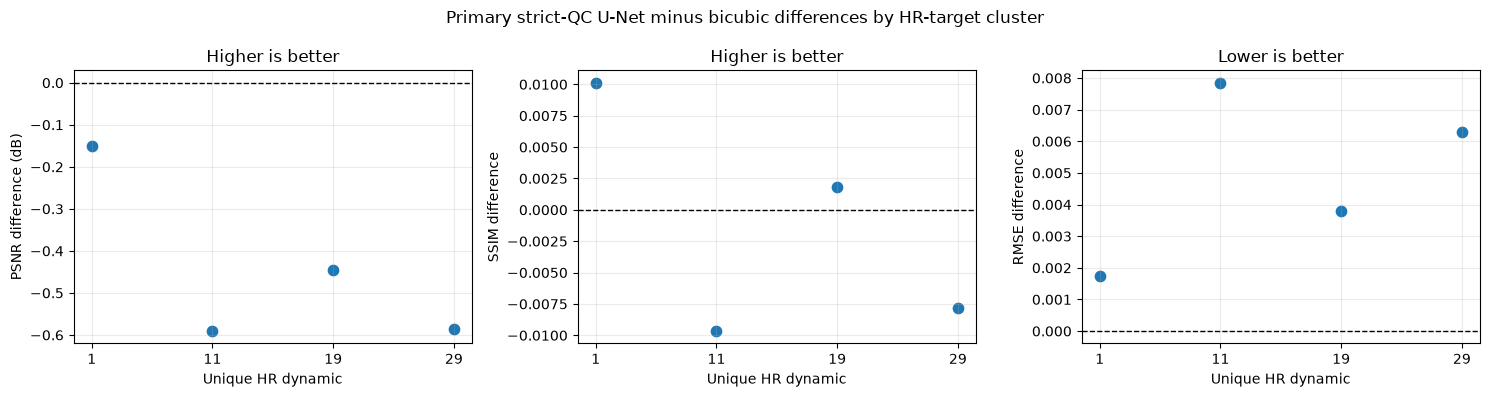

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_specs = [
    ("psnr_difference", "PSNR difference (dB)", "Higher is better"),
    ("ssim_difference", "SSIM difference", "Higher is better"),
    ("rmse_difference", "RMSE difference", "Lower is better"),
]
for ax, (column, ylabel, subtitle) in zip(axes, plot_specs):
    ax.scatter(target_differences["hr_dynamic"].astype(str), target_differences[column], s=55)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_xlabel("Unique HR dynamic")
    ax.set_ylabel(ylabel)
    ax.set_title(subtitle)
    ax.grid(alpha=0.25)
fig.suptitle("Primary strict-QC U-Net minus bicubic differences by HR-target cluster")
plt.tight_layout()
plt.show()


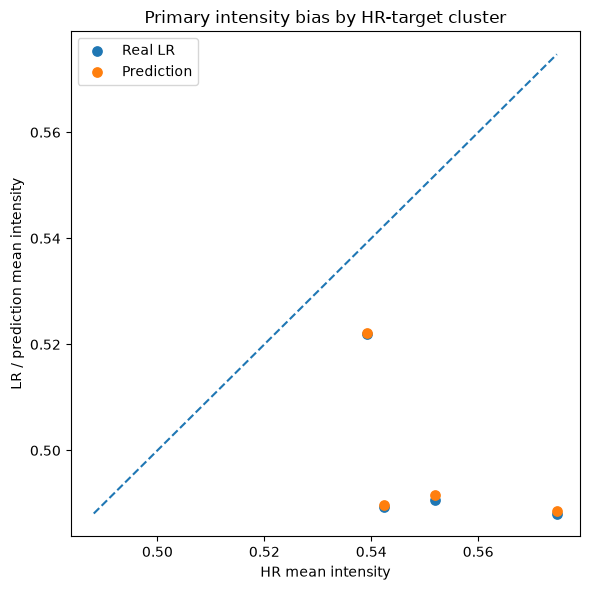

In [24]:
lower = min(
    hr_target_results["hr_mean"].min(),
    hr_target_results["lr_mean"].min(),
    hr_target_results["prediction_mean"].min(),
)
upper = max(
    hr_target_results["hr_mean"].max(),
    hr_target_results["lr_mean"].max(),
    hr_target_results["prediction_mean"].max(),
)

plt.figure(figsize=(6, 6))
plt.scatter(
    hr_target_results["hr_mean"],
    hr_target_results["lr_mean"],
    s=45,
    label="Real LR",
)
plt.scatter(
    hr_target_results["hr_mean"],
    hr_target_results["prediction_mean"],
    s=45,
    label="Prediction",
)
plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("HR mean intensity")
plt.ylabel("LR / prediction mean intensity")
plt.title("Primary intensity bias by HR-target cluster")
plt.legend()
plt.tight_layout()
plt.show()

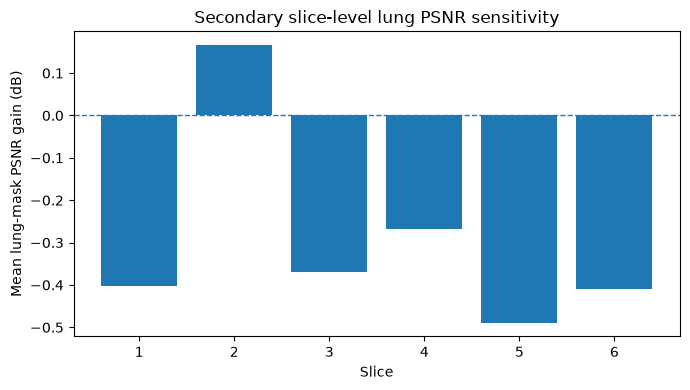

In [25]:
slice_summary = (
    results[results["primary_qc"]]
    .groupby("slice")["lung_psnr_gain"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(slice_summary.index.astype(str), slice_summary.values)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Slice")
plt.ylabel("Mean lung-mask PSNR gain (dB)")
plt.title("Secondary slice-level lung PSNR sensitivity")
plt.tight_layout()
plt.show()


In [26]:
# Exploratory whole-crop LPIPS comparison. LPIPS was trained on natural RGB images,
# so it is a secondary perceptual diagnostic rather than a validated MRI endpoint.
try:
    import lpips
except ImportError as exc:
    raise ImportError("Install the LPIPS package in the IQT environment with: pip install lpips") from exc

LPIPS_BACKBONE = "alex"
lpips_model = lpips.LPIPS(net=LPIPS_BACKBONE, verbose=False).to(DEVICE).eval()


def to_lpips_tensor(images):
    tensor = torch.from_numpy(np.asarray(images, dtype=np.float32)).unsqueeze(1).to(DEVICE)
    return tensor.repeat(1, 3, 1, 1).mul(2.0).sub(1.0)


def lpips_scores(images, targets, batch_size=BATCH_SIZE):
    assert images.shape == targets.shape
    scores = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            stop = min(start + batch_size, len(images))
            image_batch = to_lpips_tensor(images[start:stop])
            target_batch = to_lpips_tensor(targets[start:stop])
            scores.append(lpips_model(image_batch, target_batch, normalize=False).flatten().cpu().numpy())
    return np.concatenate(scores)


assert linear_images.shape == lr_images.shape == pred_images.shape == hr_images.shape
results["linear_lpips"] = lpips_scores(linear_images, hr_images)
results["baseline_lpips"] = lpips_scores(lr_images, hr_images)
results["model_lpips"] = lpips_scores(pred_images, hr_images)
results["lpips_difference"] = results["model_lpips"] - results["baseline_lpips"]
results.to_csv(RESULTS_PATH, index=False)

primary_lpips_pair_results = (
    results[results["primary_qc"]]
    .groupby(["lr_dynamic", "hr_dynamic"], as_index=False)
    .mean(numeric_only=True)
)
primary_lpips_target_results = primary_lpips_pair_results.groupby("hr_dynamic", as_index=False).mean(numeric_only=True)
assert len(primary_lpips_target_results) == results.loc[results["primary_qc"], "hr_dynamic"].nunique()

lpips_rows = []
for method, column in {"Linear": "linear_lpips", "Bicubic": "baseline_lpips", "U-Net": "model_lpips"}.items():
    values = primary_lpips_target_results[column]
    lpips_rows.append({"Method": method, "LPIPS": f"{values.mean():.4f} ± {values.std(ddof=SUMMARY_DDOF):.4f}"})

print("EXPLORATORY SECONDARY RESULT: whole-crop LPIPS, mean ± sample SD across unique HR targets")
print("Lower LPIPS is better. Grayscale images are repeated across three channels for the pretrained AlexNet network.")
display(pd.DataFrame(lpips_rows).style.hide(axis="index"))

lpips_difference = primary_lpips_target_results["model_lpips"] - primary_lpips_target_results["baseline_lpips"]
lpips_q1, lpips_q3 = lpips_difference.quantile([0.25, 0.75])
print("\nU-Net minus bicubic LPIPS across HR-target clusters:")
print(f"  mean ± sample SD: {lpips_difference.mean():+.4f} ± {lpips_difference.std(ddof=SUMMARY_DDOF):.4f}")
print(f"  median: {lpips_difference.median():+.4f}")
print(f"  IQR: [{lpips_q1:+.4f}, {lpips_q3:+.4f}]")
print(f"  range: [{lpips_difference.min():+.4f}, {lpips_difference.max():+.4f}]")
print(f"  HR targets improved: {(lpips_difference < 0).sum()}/{len(lpips_difference)} ({(lpips_difference < 0).mean() * 100:.1f}%)")
print("WARNING: LPIPS is exploratory here because its perceptual calibration is not MRI-specific.")
print("saved LPIPS columns to:", RESULTS_PATH)


c:\Users\User\anaconda3\envs\IQT-new\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\IQT-new\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EXPLORATORY SECONDARY RESULT: whole-crop LPIPS, mean ± sample SD across unique HR targets
Lower LPIPS is better. Grayscale images are repeated across three channels for the pretrained AlexNet network.


Method,LPIPS
Linear,0.1961 ± 0.0093
Bicubic,0.1602 ± 0.0106
U-Net,0.1173 ± 0.0122



U-Net minus bicubic LPIPS across HR-target clusters:
  mean ± sample SD: -0.0429 ± 0.0078
  median: -0.0432
  IQR: [-0.0483, -0.0377]
  range: [-0.0511, -0.0340]
  HR targets improved: 4/4 (100.0%)
saved LPIPS columns to: c:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\iqt_real_final_train_test_metrics.csv
